In [52]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')


# # # # # # # # # # # 
mtype = 'contra'
save = True
# # # # # # # # # # # 

if mtype=='salsa':
    version = '2022041804_04' 
elif mtype=='contra':
    version = '2022041807_a03' 
elif mtype=='ae':
    version = '2022041809_a04' 
    
from datetime import datetime
today = datetime.today().strftime('%Y%m%d%H')
    
d = 'euc'
    
tag = '_'.join([today, mtype,version,'2000n_test',d])
print(tag)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2022050223_contra_2022041807_a03_2000n_test_euc


## 1) Get latent codes.

In [53]:
rdir = '/home/kat/Repos/SALSA/results/'
mdir = '/home/kat/Repos/SALSA/data/model_ready/'

In [54]:
from eval_functions import *

which_test = '01'
test_ood = False
test_extended = False

which_train = '01'
samp_size = 2000
n_epochs = 30

eval_bs = 48
use_cuda = True
empty_cuda = True
cuda_ids = [0,1,2,3]

df, latents = get_df_and_latents(version, which_train, which_test, test_ood, test_extended,
                                 samp_size, eval_bs, n_epochs, use_cuda, empty_cuda, cuda_ids)

anc_path = f'{mdir}{which_test}/test/anchor_smiles.csv'
aug_path = f'{mdir}{which_test}/test/augmented_smiles.csv'   
# ds = ContraSeqDataset(anc_path, aug_path)
ds_arr = get_dataset_array(anc_path, aug_path)
anc_map = get_anc_map(ds_arr)

from tqdm.notebook import tqdm
from scipy.spatial import distance
from itertools import combinations as combo

anc_aug_dists = []
far = []
for anc,augs in tqdm(anc_map.items(), total=len(anc_map)):
    augs = list(augs)
    augs.pop(0)
    
    latent_anc = latents[anc]    
    for aug in augs:
        latent_aug = latents[aug]
        d = distance.euclidean(latent_anc, latent_aug)
        if d > 1:
            far.append(anc)
        anc_aug_dists.append(d)
        
dist_arr = np.array(anc_aug_dists)        
if save:
    txt_out = f'{rdir}anc_aug_dists/{tag}.txt'
    np.savetxt(txt_out, dist_arr)

Using 4 GPUs!
Loaded model weights from /home/kat/Repos/SALSA/results/models/2022041807_a03/29.pt!
Loaded evaluation data from /home/kat/Repos/SALSA/data/model_ready/01/test/anchor_smiles.csv!


  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

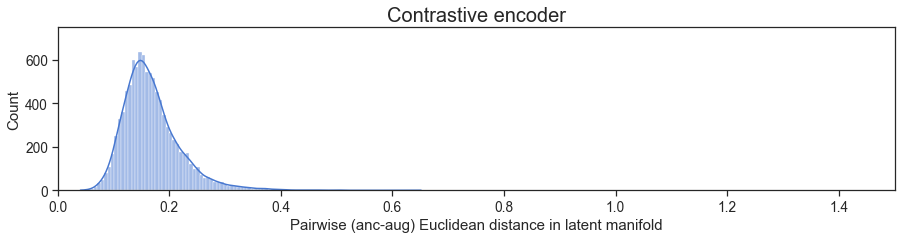

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='ticks',font_scale=1.25,palette='muted')

if mtype=='salsa':
    t = 'SALSA (Graph-constrastive autoencoder)'
elif mtype=='contra':
    t = 'Contrastive encoder'
elif mtype=='ae':
    t = 'Vanilla autoencoder'

ylim = 750
bns = 100

plt.figure(figsize=(15,3))
plt.title(t,fontsize=20)
plt.xlabel('Pairwise (anc-aug) Euclidean distance in latent manifold')

plt.ylim(0,ylim) #700
plt.xlim(0,1.5)

sns.histplot(anc_aug_dists, bins=bns, kde=True)

plt.savefig(f'{rdir}plot_figs/{tag}_{bns}bins_ylim{ylim}.png', bbox_inches='tight')
plt.show()

In [4]:
# from tqdm.notebook import tqdm
# from scipy.spatial import distance
# from itertools import combinations as combo

# all_dists = []

# for idc_pair in tqdm(combo(range(len(latents)),2), total=len(latents)**2//2):
#     idx1, idx2 = idc_pair
#     if idx1==idx2:
#         continue
#     latent1 = latents[idx1]    
#     latent2 = latents[idx2]    
#     d = distance.euclidean(latent1, latent2)
#     all_dists.append(d)
# print(len(all_dists))